## Imports and Configs

In [ ]:
!python -c "import monai" || pip install -q "monai[nibabel, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
!python -c "import onnxruntime" || pip install -q onnxruntime
!pip install -q SimpleITK-SimpleElastix
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.0 MB/s eta 0:00:00
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'onnxruntime'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 18.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import tempfile
import time
import matplotlib.pyplot as plt
from monai.config import print_config
from monai.data import DataLoader, decollate_batch, CacheDataset
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss, DiceCELoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import SegResNet, UNet, UNETR
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    RandRotate90d,
    Spacingd,
    EnsureTyped,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandCropByLabelClassesd,
    Resize,
    ToTensord,
)
import monai
import numpy as np
import nibabel as nib
from glob import glob
import torch
from monai.utils import set_determinism
import onnxruntime
from tqdm import tqdm
from monai.transforms import Compose
import SimpleITK as sitk
from monai.transforms import MapTransform
import warnings
warnings.filterwarnings("ignore")
from torch.optim.lr_scheduler import ReduceLROnPlateau
# print_config()

# from nnunet.network_architecture.generic_UNet import Generic_UNet
# from nnunet.training.network_training.nnUNetTrainerV2 import nnUNetTrainerV2
# from nnunet.utilities.plans_handling.plans import load_plans_from_file
# from nnunet.paths import default_plans_identifier, network_training_output_dir


In [ ]:
# Set deterministic training for reproducibility
set_determinism(seed=42)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set CUDA device order
torch.backends.cudnn.benchmark = True
root_dir = "/content/drive/MyDrive/projects/MISA"

## Data preprocessing and loading

In [ ]:
class BiasFieldCorrection(MapTransform):
    """
    Applies N4 bias field correction to the input image.

    Args:
        keys: Keys of the corresponding items to be transformed.
            See also: :py:class:`monai.transforms.compose.MapTransform`
    """

    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        """
        Args:
            data: is a dictionary containing the image data to be processed
        """
        d = dict(data)
        for key in self.keys:
            d[key] = self.bias_correct(d[key])
        return d

    def bias_correct(self, image):
        """
        Performs N4 bias field correction using SimpleITK.

        Args:
            image: The input image as a SimpleITK Image object.

        Returns:
            The bias-corrected image as a SimpleITK Image object.
        """
        # Convert the NumPy array to a SimpleITK Image
        image = sitk.GetImageFromArray(image)

        # Check if the image is already of type sitkFloat32
        if image.GetPixelID() != sitk.sitkFloat32:
            image = sitk.Cast(image, sitk.sitkFloat32) # Cast only if it's not already sitkFloat32

        corrected_image = sitk.N4BiasFieldCorrection(image)

        # Convert the corrected SimpleITK Image back to a NumPy array
        corrected_image = sitk.GetArrayFromImage(corrected_image)
        return corrected_image

def dice_coefficient(segmented_image: np.ndarray, gt_labels: np.ndarray, label: int) -> float:
    """Calculate Dice coefficient for a specific label.

    Args:
        segmented_image (np.ndarray): Predicted segmentation
        gt_labels (np.ndarray): Ground truth labels
        label (int): Label to calculate Dice coefficient for

    Returns:
        float: Dice coefficient value between 0 and 1
    """
    seg_mask = segmented_image == label
    gt_mask = gt_labels == label

    intersection = np.sum(seg_mask & gt_mask)
    denominator = np.sum(seg_mask) + np.sum(gt_mask)

    return (2.0 * intersection) / denominator if denominator > 0 else 0.0

def show_results(image, gt, prediction, modality='T1', i=0, slice_idx=150, plot=True, show_hist=True, cmap='tab20'):
    csf, gm, wm = dice_coefficient(prediction, gt, 1), dice_coefficient(prediction, gt, 2), dice_coefficient(prediction, gt, 3)
    print(f'Dice Score: CSF: {csf}, GM: {gm}, WM: {wm}, Avg: {(csf+gm+wm)/3}')
    if plot:
        slice_idx = slice_idx
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 5, 1)
        plt.imshow(image[slice_idx], cmap='gray')
        plt.title(f'Original Image Slice for {modality} image {i+1}')
        plt.axis('off')

        plt.subplot(1, 5, 2)
        plt.imshow(gt[slice_idx], cmap='gray')
        plt.title('Ground Truth Slice')
        plt.axis('off')

        plt.subplot(1, 5, 3)
        plt.imshow(prediction[slice_idx], cmap='gray')
        plt.title('Segmented Image Slice')
        plt.axis('off')
        plt.tight_layout()

        # plot overlay
        overlay = np.zeros_like(image[slice_idx])
        overlay[prediction[slice_idx] == 1] = 1
        overlay[prediction[slice_idx] == 2] = 2
        overlay[prediction[slice_idx] == 3] = 3
        plt.subplot(1, 5, 4)
        plt.imshow(image[slice_idx], cmap='gray')
        plt.imshow(overlay, cmap=cmap, alpha=0.5)
        plt.title('Prediction Overlay')
        plt.axis('off')

        # ground truth overlay
        overlay_gt = np.zeros_like(image[slice_idx])
        overlay_gt[gt[slice_idx] == 1] = 1
        overlay_gt[gt[slice_idx] == 2] = 2
        overlay_gt[gt[slice_idx] == 3] = 3
        plt.subplot(1, 5, 5)
        plt.imshow(image[slice_idx], cmap='gray')
        plt.imshow(overlay_gt, cmap=cmap, alpha=0.5)
        plt.title('Ground Truth Overlay')
        plt.axis('off')

        if show_hist:
            # plot histogram
            plt.figure(figsize=(15, 6))
            plt.subplot(1, 3, 1)
            plt.hist(image[slice_idx].ravel(), bins=256, histtype='step', color='black')
            plt.title(f'Original Image Histogram for {modality} image {i+1}')
            plt.xlabel('Intensity')
            plt.ylabel('Frequency')

            plt.subplot(1, 3, 2)
            plt.hist(gt[slice_idx].ravel(), bins=256, histtype='step', color='black')
            plt.title('Ground Truth Histogram')
            plt.xlabel('Intensity')
            plt.ylabel('Frequency')

            plt.subplot(1, 3, 3)
            plt.hist(prediction[slice_idx].ravel(), bins=256, histtype='step', color='black')
            plt.title('Segmented Image Histogram')
            plt.xlabel('Intensity')
            plt.ylabel('Frequency')
            plt.tight_layout()


        plt.show()
    return csf, gm, wm

In [ ]:
train_root_dir = "/content/drive/MyDrive/projects/MISA/Training_Set"
subdirs = sorted(os.listdir(train_root_dir))
images = []
labels = []

for subdir in subdirs:
    img_path = os.path.join(train_root_dir, subdir, f"{subdir}.nii.gz")
    lbl_path = os.path.join(train_root_dir, subdir, f"{subdir}_seg.nii.gz")
    if os.path.exists(img_path) and os.path.exists(lbl_path):
        images.append(img_path)
        labels.append(lbl_path)

# Create dictionary items for each image-label pair
train_files = [{"image": img, "label": lbl} for img, lbl in zip(images, labels)]

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.5, 1.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    # BiasFieldCorrection(keys=["image"]),
    ScaleIntensityRanged(keys="image", a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByLabelClassesd(keys=["image", "label"], label_key="label", spatial_size=(96, 96, 96), num_classes=4, ratios=[0, 1, 1, 1], num_samples=4, image_key="image"),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0]),
    RandFlipd(keys=["image", "label"], spatial_axis=[1],prob=0.10,),
    RandFlipd(keys=["image", "label"],spatial_axis=[2],prob=0.10,),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    RandShiftIntensityd(keys=["image"],offsets=0.10, prob=0.50,),
    ToTensord(keys=["image", "label"]),
])

# Create CacheDataset and DataLoader for efficient data handling
train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=0.8, num_workers=4)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=4)

val_root_dir = "/content/drive/MyDrive/projects/MISA/Validation_Set"
subdirs = sorted(os.listdir(val_root_dir))
images = []
labels = []

for subdir in subdirs:
    img_path = os.path.join(val_root_dir, subdir, f"{subdir}.nii.gz")
    lbl_path = os.path.join(val_root_dir, subdir, f"{subdir}_seg.nii.gz")
    if os.path.exists(img_path) and os.path.exists(lbl_path):
        images.append(img_path)
        labels.append(lbl_path)

# Create dictionary items for each image-label pair
val_files = [{"image": img, "label": lbl} for img, lbl in zip(images, labels)]

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.5, 1.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    # BiasFieldCorrection(keys=["image"]),
    ScaleIntensityRanged(keys="image", a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"]),
])

val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4)


# Test data directory
test_root_dir = "/content/drive/MyDrive/projects/MISA/Test_Set"
# Load test data and apply transforms
test_images = sorted(glob(os.path.join(test_root_dir, "*", "*.nii.gz")))
test_data = [{"image": img} for img in test_images]
test_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.0, 1.5, 1.0), mode=("bilinear")),
    Orientationd(keys=["image"], axcodes="RAS"),
    # BiasFieldCorrection(keys=["image"]),
    ScaleIntensityRanged(keys="image", a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image"], source_key="image"),
])

test_ds = CacheDataset(data=test_data, transform=test_transforms, cache_rate=1.0, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=4)

post_transforms = Compose(
    [
        Invertd(
            keys="pred",
            transform=val_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
            device="cpu",
        ),

    ])

Loading dataset: 100%|██████████| 3/3 [00:01<00:00,  2.71it/s]


## Model Development

In [ ]:
# Model initialization function
def initialize_model(model_name, model_dir=None, plans_file=None):
    if model_name == "UNETR":
        model = UNETR(
            in_channels=1,
            out_channels=4,
            img_size=(96, 96, 96),
            feature_size=16,
            hidden_size=768,
            mlp_dim=3072,
            num_heads=12,
            proj_type="perceptron",
            norm_name="instance",
            res_block=True,
            dropout_rate=0.0,
        )
    elif model_name == "ResUNet":
        model = monai.networks.nets.UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=4,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm="instance",
        )
    elif model_name == "SwinUNETR":
        model = monai.networks.nets.SwinUNETR(
            img_size=(96, 96, 96),
            in_channels=1,
            out_channels=4,
            feature_size=48,
            use_checkpoint=True,
        )
    elif model_name == "BasicUNet":
        model = monai.networks.nets.BasicUNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=4,
            norm="instance",
        )
    elif model_name == "nnUNet":
        if plans_file is None:
            raise ValueError("For nnUNet, plans_file must be provided.")
        plans = load_plans_from_file(plans_file)
        model_trainer = nnUNetTrainerV2(plans=plans, fold=0)
        model = model_trainer.network
    else:
        raise ValueError(f"Model {model_name} is not supported.")
    return model.to(device)


# Validation function
def validation(val_loader, model, loss_function, post_label, post_pred, dice_metric):
    model.eval()
    val_loss = 0
    val_steps = 0
    with torch.no_grad():
        for batch in val_loader:
            val_inputs, val_labels = batch["image"].to(device), batch["label"].to(device)
            val_outputs = sliding_window_inference(val_inputs, (96, 96, 96), 4, model)
            val_loss += loss_function(val_outputs, val_labels).item()
            val_labels_list = decollate_batch(val_labels)
            val_labels_convert = [post_label(val_label_tensor) for val_label_tensor in val_labels_list]
            val_outputs_list = decollate_batch(val_outputs)
            val_output_convert = [post_pred(val_pred_tensor) for val_pred_tensor in val_outputs_list]
            dice_metric(y_pred=val_output_convert, y=val_labels_convert)
            val_steps += 1
    mean_dice_val = dice_metric.aggregate().item()
    dice_metric.reset()
    mean_val_loss = val_loss / val_steps
    return mean_dice_val, mean_val_loss

def plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name):
    plt.figure(figsize=(12, 6))

    # Plot losses
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_values, label='Train Loss')
    plt.plot(val_loss_values, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training and Validation Loss for {model_name}')
    plt.legend()
    plt.grid(True)


    # Plot Dice scores
    plt.subplot(1, 2, 2)
    plt.plot(train_dice_values, label='Train Dice')
    plt.plot(val_dice_values, label='Validation Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.title(f'Training and Validation Dice Score for {model_name}')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()  # Adjusts subplot parameters for a tight layout
    plt.show()

# Training function
def train(train_loader, val_loader, model_name, max_epochs=50, patience=10):
    model = initialize_model(model_name)
    print(f"Training {model_name}...")
    dice_val_best = -1
    stop_counter = 0
    # Loss function, optimizer, and scheduler
    loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    # Metric definitions
    dice_metric = DiceMetric(include_background=True, reduction="mean", get_not_nans=False)
    post_label = AsDiscrete(to_onehot=4)
    post_pred = AsDiscrete(argmax=True, to_onehot=4)

    # Training parameters
    max_epochs = max_epochs
    early_stopping_patience = patience
    eval_num = 5
    # Metric tracking lists
    train_loss_values = []
    val_loss_values = []
    train_dice_values = []
    val_dice_values = []
    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0
        train_dice = 0
        step = 0
        epoch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", dynamic_ncols=True)
        for step, batch in enumerate(epoch_iterator):
            x, y = batch["image"].to(device), batch["label"].to(device)
            logit_map = model(x)
            loss = loss_function(logit_map, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Metrics calculations
            epoch_loss += loss.item()
            logit_map_list = decollate_batch(logit_map)
            logit_map_convert = [post_pred(pred) for pred in logit_map_list]
            y_list = decollate_batch(y)
            y_convert = [post_label(label) for label in y_list]
            dice_metric(y_pred=logit_map_convert, y=y_convert)
            train_dice += dice_metric.aggregate().item()
            dice_metric.reset()

            epoch_iterator.set_postfix(loss=loss.item())

        epoch_loss /= (step + 1)
        train_dice /= (step + 1)
        train_loss_values.append(epoch_loss)
        train_dice_values.append(train_dice)

        # Validation
        epoch_iterator_val = tqdm(val_loader, desc="Validation", dynamic_ncols=True)
        val_dice, val_loss = validation(epoch_iterator_val, model, loss_function, post_label, post_pred, dice_metric)
        val_loss_values.append(val_loss)
        val_dice_values.append(val_dice)

        # Update scheduler
        scheduler.step(val_loss)

        # Early stopping check
        if val_dice > dice_val_best:
            dice_val_best = val_dice
            stop_counter = 0
            torch.save(model.state_dict(), os.path.join(root_dir, f"best_{model_name}_model.pth"))
            print(f"Epoch {epoch+1}: Model saved with dice {val_dice:.4f}")
        else:
            stop_counter += 1
            print(f"Epoch {epoch+1}: No improvement (Best dice {dice_val_best:.4f}), early stopping counter: {stop_counter}/{early_stopping_patience}")

        # Check early stopping condition
        if stop_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    # Load the best model for final evaluation
    model.load_state_dict(torch.load(os.path.join(root_dir, f"best_{model_name}_model.pth")))
    return train_loss_values, val_loss_values, train_dice_values, val_dice_values

In [ ]:
def save_val_pred(model, val_loader, output_dir, model_path):
    os.makedirs(output_dir, exist_ok=True)
    model.load_state_dict(torch.load(os.path.join(root_dir, model_path), map_location=device))
    model.eval()
    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)

            # Get metadata directly from the input image's meta attribute
            original_affine = val_data["image"].meta["affine"][0].cpu().numpy()
            val_data["pred"] = sliding_window_inference(val_inputs, (96, 96, 96), 4, model, overlap=0.3)
            val_data = [post_transforms(i) for i in decollate_batch(val_data)]

            val_outputs = val_data[0]["pred"]

            # Post-processing and saving
            seg_map = torch.argmax(val_outputs, dim=0).detach().cpu().numpy()

            seg_img = nib.Nifti1Image(seg_map.astype(np.uint8), original_affine)

            val_image_name = os.path.basename(val_data[0]["image"].meta["filename_or_obj"])
            output_path = os.path.join(output_dir, val_image_name.replace(".nii.gz", "_pred_seg.nii.gz"))
            nib.save(seg_img, output_path)

    return f"Val predictions saved to: {output_dir}"

def test_and_save_predictions(model, test_loader, model_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    model.load_state_dict(torch.load(os.path.join(root_dir, model_path), map_location=device))
    model.eval()
    with torch.no_grad():
        for test_data in test_loader:
            test_inputs = test_data["image"].to(device)

            # Get metadata directly from the input image's meta attribute
            original_affine = test_data["image"].meta["affine"][0].cpu().numpy()

            test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 4, model, overlap=0.3)
            test_data = [post_transforms(i) for i in decollate_batch(test_data)]

            test_outputs = test_data[0]["pred"]

            # Post-processing and saving
            # Post-processing and saving
            seg_map = torch.argmax(test_outputs, dim=0).detach().cpu().numpy()

            seg_img = nib.Nifti1Image(seg_map.astype(np.uint8), original_affine)

            test_image_name = os.path.basename(test_data[0]["image"].meta["filename_or_obj"])
            output_path = os.path.join(output_dir, test_image_name.replace(".nii.gz", "_seg.nii.gz"))
            nib.save(seg_img, output_path)

    return f"Predictions saved to: {output_dir}"

## Model Training

### UNet

In [ ]:
model_name = "BasicUNet"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15)

BasicUNet features: (32, 32, 64, 128, 256, 32).
Training BasicUNet...


Validation: 100%|██████████| 5/5 [00:02<00:00,  1.88it/s]


Epoch 1: Model saved with dice 0.5754


Validation: 100%|██████████| 5/5 [00:01<00:00,  2.62it/s]


Epoch 2: Model saved with dice 0.6358


...

Epoch 95: No improvement (Best dice 0.9280), early stopping counter: 13/15


Validation: 100%|██████████| 5/5 [00:01<00:00,  2.59it/s]


Epoch 96: No improvement (Best dice 0.9280), early stopping counter: 14/15


Validation: 100%|██████████| 5/5 [00:01<00:00,  2.56it/s]

Epoch 97: No improvement (Best dice 0.9280), early stopping counter: 15/15
Early stopping triggered.


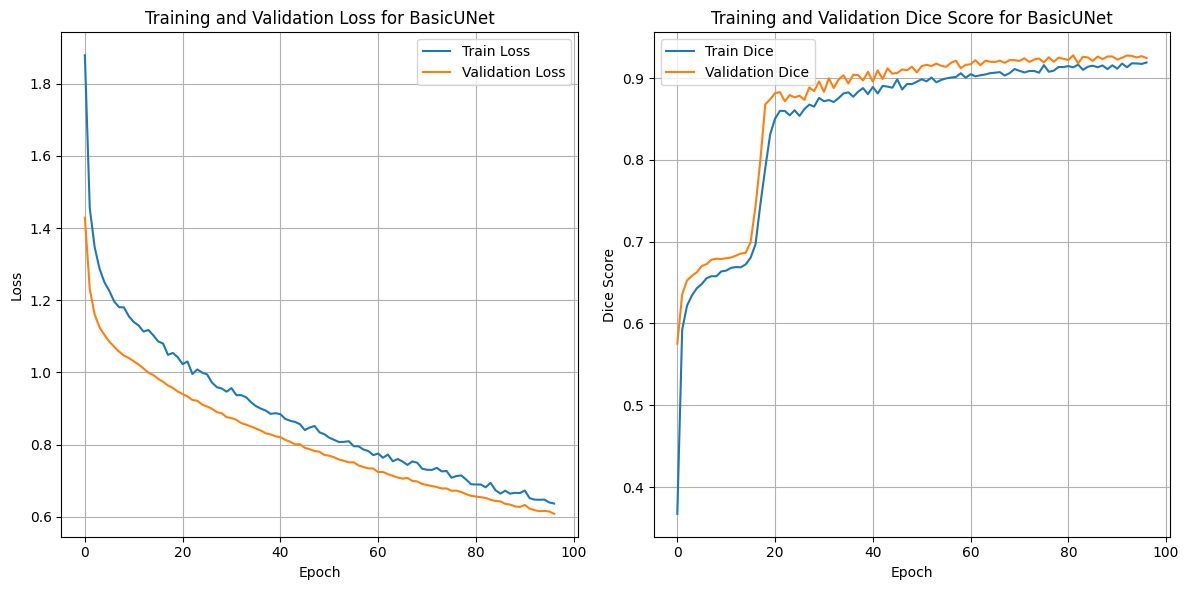

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "BasicUNet"
model = initialize_model(model_name)
output_dir = os.path.join(root_dir, "BasicUNet_Val_Preds")
save_val_pred(model, val_loader, output_dir)

### UNETR

In [ ]:
model_name = "UNETR"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15)

Training UNETR...


Validation: 100%|██████████| 5/5 [00:03<00:00,  1.32it/s]


Epoch 1: Model saved with dice 0.5782


Validation: 100%|██████████| 5/5 [00:02<00:00,  2.44it/s]


Epoch 2: Model saved with dice 0.6335


...

Epoch 98: No improvement (Best dice 0.9036), early stopping counter: 3/15


Validation: 100%|██████████| 5/5 [00:02<00:00,  2.32it/s]


Epoch 99: No improvement (Best dice 0.9036), early stopping counter: 4/15


Validation: 100%|██████████| 5/5 [00:02<00:00,  2.37it/s]


Epoch 100: No improvement (Best dice 0.9036), early stopping counter: 5/15


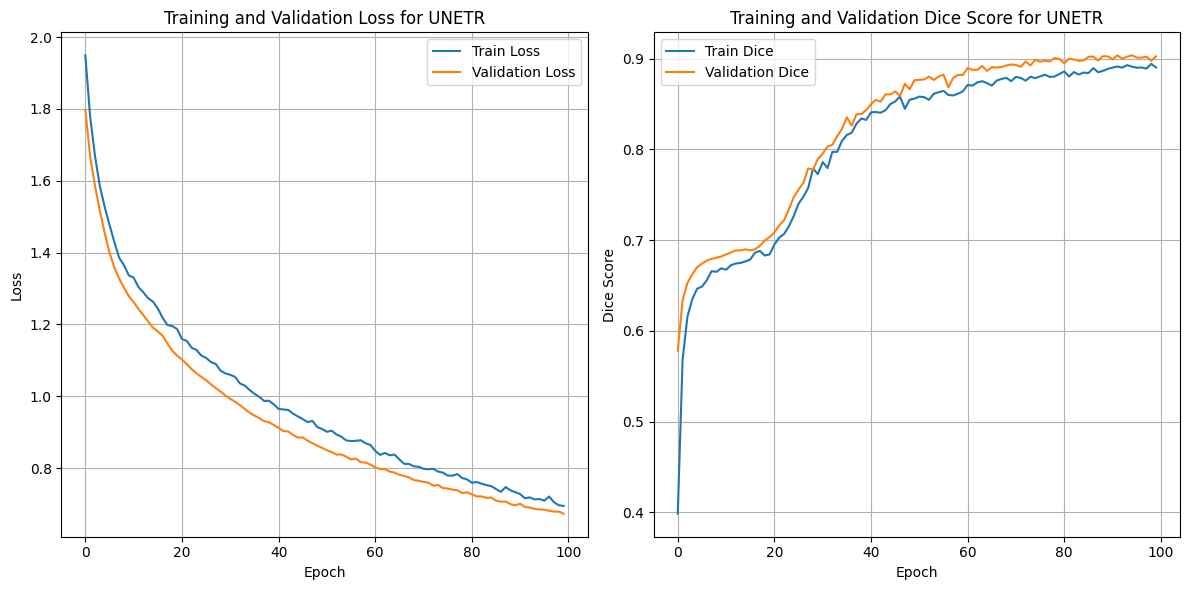

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "UNETR"
model = initialize_model(model_name)
output_dir = os.path.join(root_dir, "UNETR_Val_Preds")
save_val_pred(model, val_loader, output_dir)

### SwinUnet

In [ ]:
model_name = "SwinUNETR"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15)

Training SwinUNETR...


Validation: 100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


Epoch 1: Model saved with dice 0.6520


Validation: 100%|██████████| 5/5 [00:02<00:00,  2.26it/s]


Epoch 2: Model saved with dice 0.6671


...

Epoch 76: No improvement (Best dice 0.9157), early stopping counter: 13/15


Validation: 100%|██████████| 5/5 [00:02<00:00,  2.18it/s]


Epoch 77: No improvement (Best dice 0.9157), early stopping counter: 14/15


Validation: 100%|██████████| 5/5 [00:02<00:00,  2.25it/s]


Epoch 78: No improvement (Best dice 0.9157), early stopping counter: 15/15
Early stopping triggered.


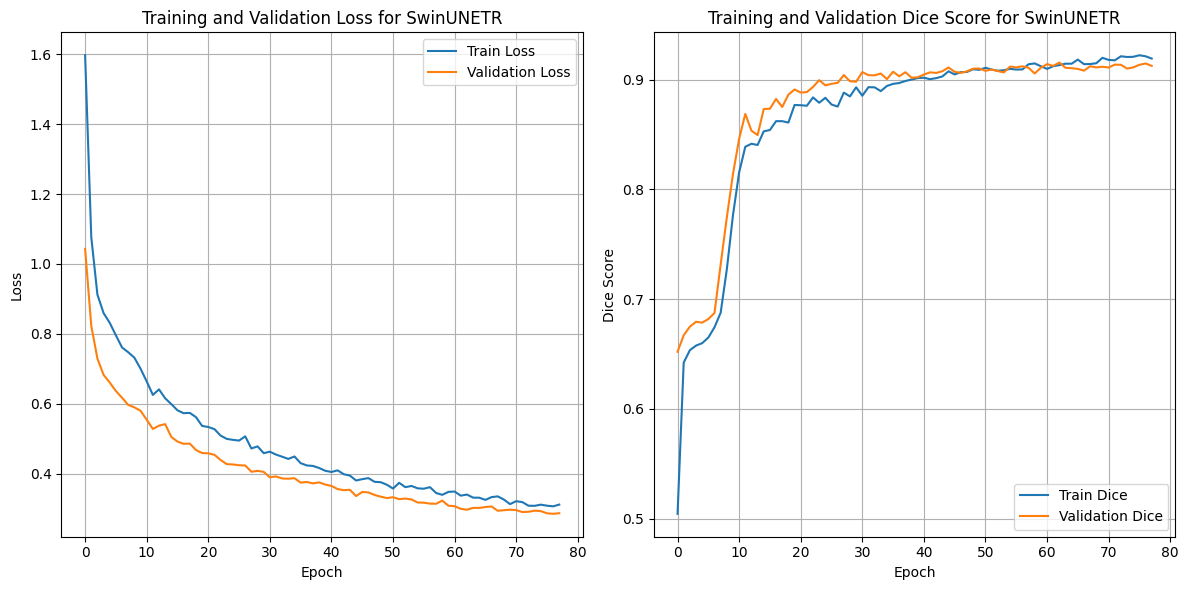

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "SwinUNETR"
model = initialize_model(model_name)
output_dir = os.path.join(root_dir, "SwinUNETR_Val_Preds")
save_val_pred(model, val_loader, output_dir)

### ResUnet

In [ ]:
model_name = "ResUNet"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15)

Training ResUNet...


Validation: 100%|██████████| 5/5 [00:04<00:00,  1.10it/s]


Epoch 1: Model saved with dice 0.2907


Validation: 100%|██████████| 5/5 [00:03<00:00,  1.63it/s]


Epoch 2: Model saved with dice 0.3565


...

Epoch 98: No improvement (Best dice 0.9044), early stopping counter: 1/15


Validation: 100%|██████████| 5/5 [00:02<00:00,  1.77it/s]


Epoch 99: No improvement (Best dice 0.9044), early stopping counter: 2/15


Validation: 100%|██████████| 5/5 [00:03<00:00,  1.30it/s]

Epoch 100: No improvement (Best dice 0.9044), early stopping counter: 3/15


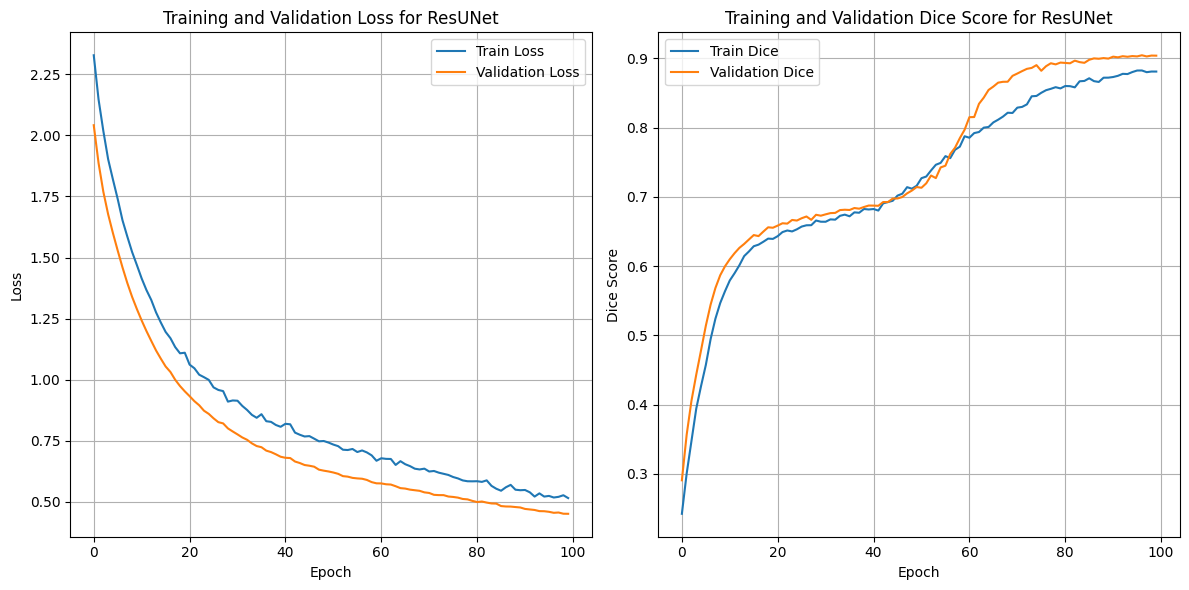

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "ResUNet"
model = initialize_model(model_name)
output_dir = os.path.join(root_dir, "ResUNet_Val_Preds")
save_val_pred(model, val_loader, output_dir)

### NN-Unet

In [ ]:
model_name = "nnUNet"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=100, patience=15)

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "nnUNet"
model = initialize_model(model_name)
output_dir = os.path.join(root_dir, "nnUNet_Val_Preds")
save_val_pred(model, val_loader, output_dir)